### Set up dataset

In [2]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [3]:
from a3em_analysis.datasets import Arden

dataset = Arden(path, token)
dataset.load_data(random_state=123, rumble_only=True)
metadata = dataset.metadata

prefetch complete
extracting features


100%|██████████| 62/62 [01:35<00:00,  1.54s/it]


### Duration over time

In [4]:
from datetime import datetime, timedelta

def parse_abs_start(row):
    parts = row['file_stem'].split('_')
    rec_start = datetime.strptime(parts[1] + parts[2], '%Y%m%d%H%M%S')
    return rec_start + timedelta(seconds=row['Begin Time (s)'])

In [5]:
metadata['abs_start'] = [parse_abs_start(row) for _, row in metadata.iterrows()]
metadata.head()

,file_stem,Begin Time (s),End Time (s),call_type,quality,overlap,earflap,duration,abs_start
0,Arden_20250607_050010,170.571151,175.953214,RUM,3,N,1,5.382062,2025-06-07 05:03:00.571151
1,Arden_20250606_150100,2356.943538,2362.128695,RUM,2,N,1,5.185158,2025-06-06 15:40:16.943538
2,Arden_20250606_220135,602.506150,608.075457,RUM,2,N,0,5.569307,2025-06-06 22:11:37.506150
3,Arden_20250607_190120,2322.122380,2327.227578,RUM,3,N,1,5.105198,2025-06-07 19:40:02.122380
4,Arden_20250608_230140,1860.792184,1863.576838,RUM,2,N,0,2.784653,2025-06-08 23:32:40.792184


<BarContainer object of 705 artists>

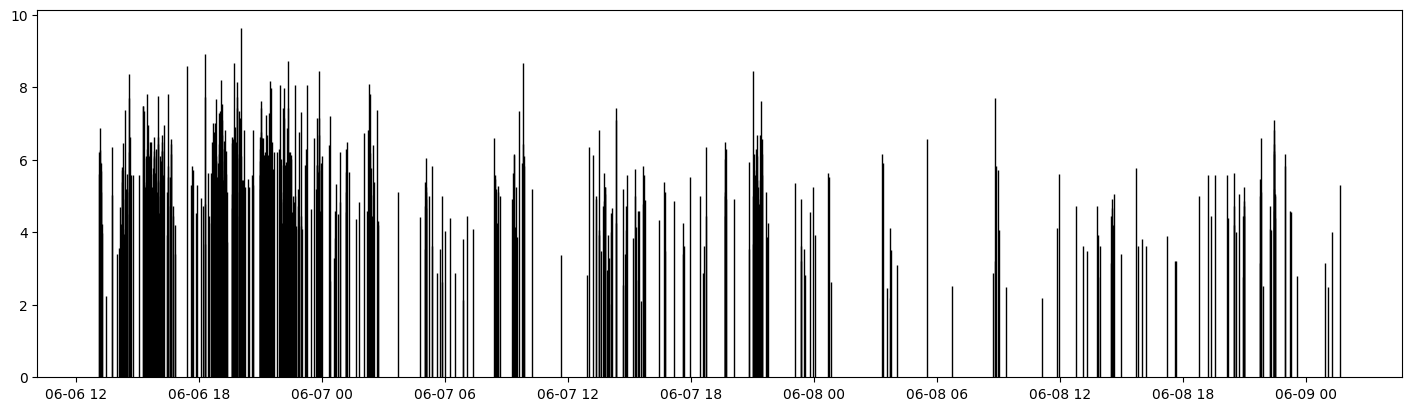

In [6]:
import matplotlib.pyplot as plt

time = metadata['abs_start'].to_numpy()
call_duration = metadata['duration'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 4), layout='constrained')
ax.bar(time, call_duration, width=1, edgecolor="black", linewidth=1)


#### Peak Frequency Over Time

In [7]:
features, _ = dataset.load_data()
features.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
0,23.437500,178.779956,133.835880,36.132812,131.835938,-1.776016,-0.076326,-198.986684,239.842074,-40.714127,...,0.004546,0.001320,0.000364,0.000096,0.000024,0.000011,0.000010,0.000009,0.000009,0.000009
1,46.875000,147.315745,120.647897,34.179688,160.156250,-7.907223,-8.424224,-309.532524,235.805844,-13.067658,...,0.000237,0.000064,0.000011,0.000004,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002
2,23.437500,194.163404,136.806571,32.226562,198.242188,-8.642805,-3.842762,-194.467466,236.761612,-48.051682,...,0.005507,0.001716,0.000412,0.000083,0.000029,0.000008,0.000005,0.000004,0.000004,0.000004
3,22.460938,151.158718,122.707804,37.109375,125.976562,-3.056880,-2.705753,-207.761279,243.125815,-22.173188,...,0.001051,0.000363,0.000063,0.000022,0.000011,0.000008,0.000008,0.000007,0.000007,0.000007
4,32.226562,250.617734,155.907884,42.968750,450.195312,4.508551,9.058329,-124.077526,237.173680,-91.292423,...,0.044213,0.010921,0.003966,0.000878,0.000247,0.000046,0.000014,0.000007,0.000005,0.000004


<BarContainer object of 705 artists>

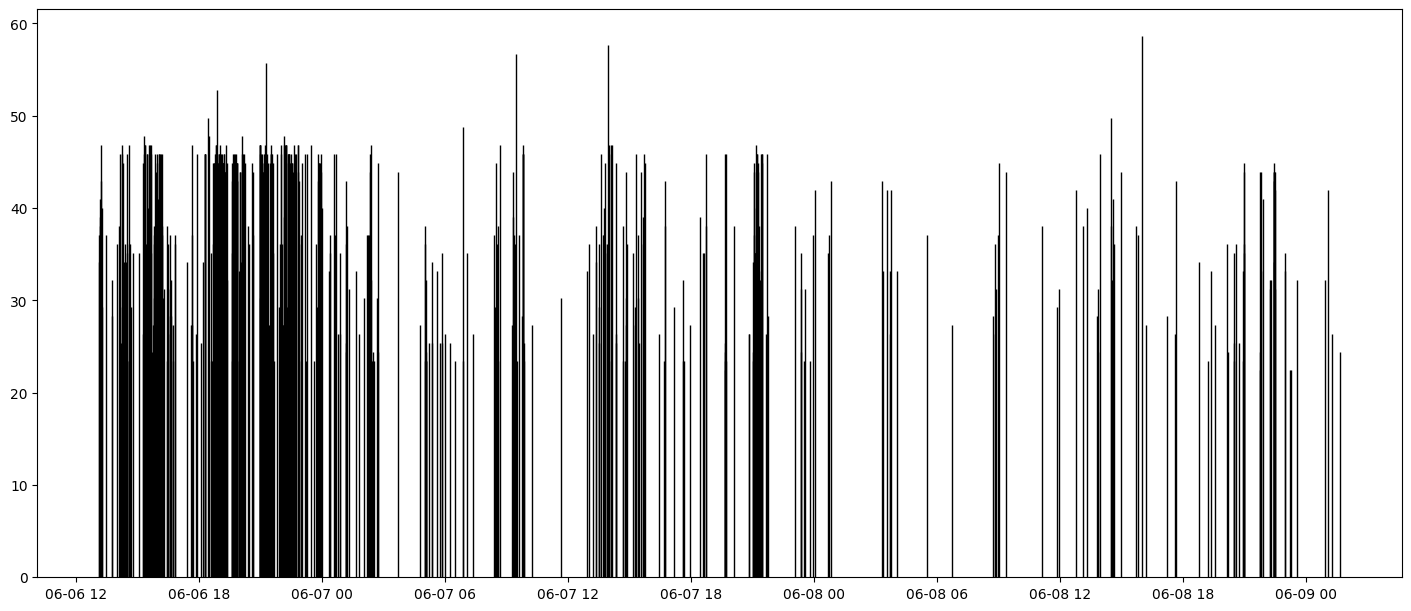

In [8]:
import matplotlib.pyplot as plt

time = metadata['abs_start'].to_numpy()
peak_freq = features['peak_freq'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
ax.bar(time, peak_freq, width=1, edgecolor="black", linewidth=1)

### Interval Aggregation

The raw per-call bar plots above are noisy. Here we aggregate duration and peak frequency into
fixed-length time intervals and report the mean ± std within each interval, at several interval
lengths, so we can pick the one that best balances noise reduction against temporal resolution.

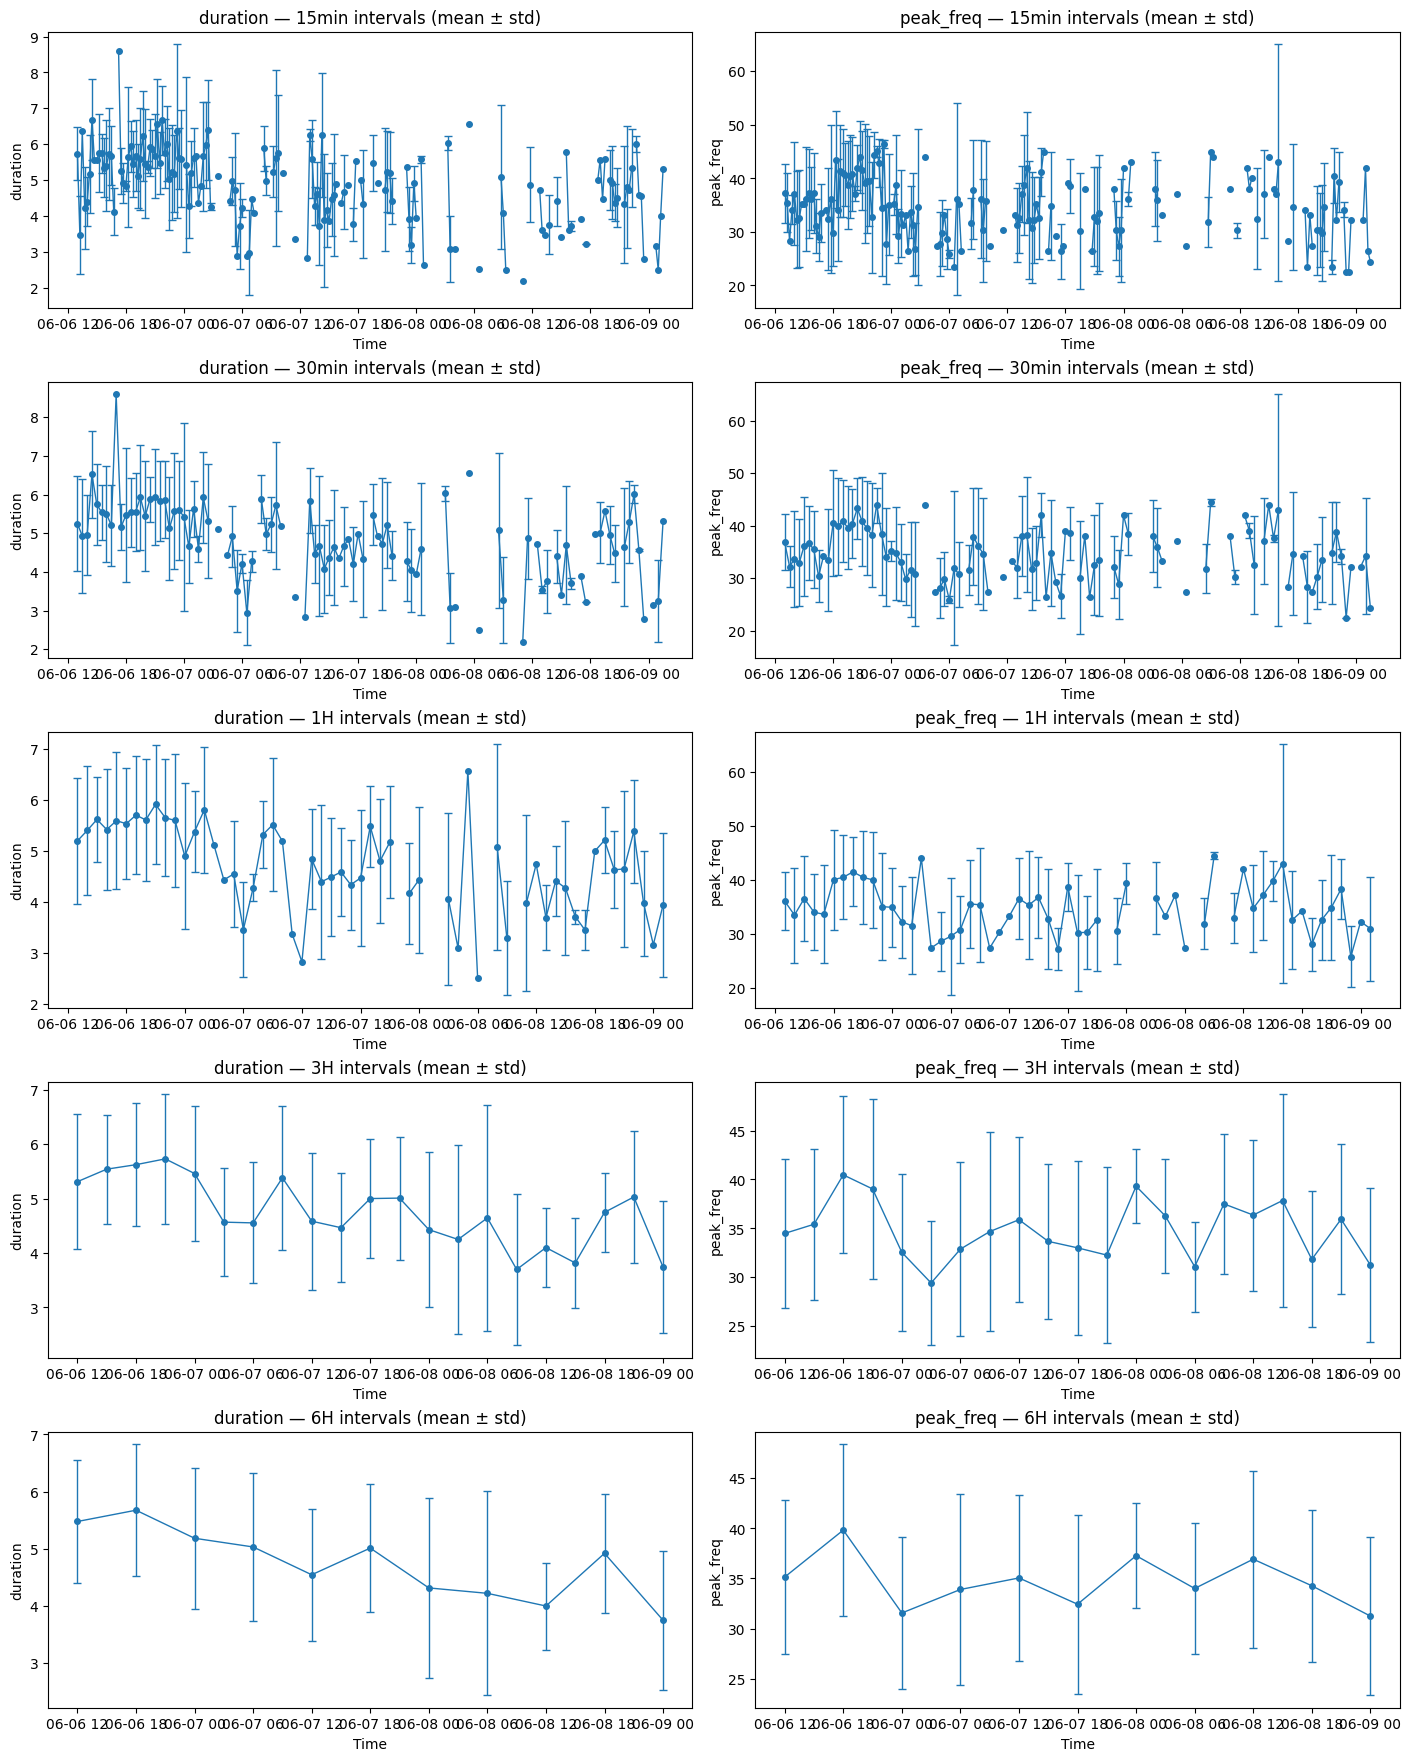

In [ ]:
import pandas as pd

call_df = pd.DataFrame({
    'duration': metadata['duration'].to_numpy(),
    'peak_freq': features['peak_freq'].to_numpy(),
}, index=pd.DatetimeIndex(metadata['abs_start'], name='abs_start')).sort_index()

interval_lengths = ['3H', '6H']
variables = ['duration', 'peak_freq']

fig, axes = plt.subplots(
    len(interval_lengths), len(variables),
    figsize=(14, 3.5 * len(interval_lengths)),
    layout='constrained'
)

for row, interval in enumerate(interval_lengths):
    grouped = call_df.resample(interval)
    mean = grouped.mean()
    std = grouped.std()

    for col, variable in enumerate(variables):
        ax = axes[row, col]
        ax.errorbar(
            mean.index, mean[variable], yerr=std[variable],
            fmt='o-', capsize=3, markersize=4, linewidth=1
        )
        ax.set_title(f'{variable} — {interval} intervals (mean ± std)')
        ax.set_xlabel('Time')
        ax.set_ylabel(variable)

plt.show()


### Correlation: Duration vs. Peak Frequency

Gyory noted similar trends between duration and peak frequency in the plots above. We test that
here with a correlation analysis. Since these features are not normally distributed (as established
in `initial_analysis.ipynb`), we use Spearman's rank correlation as the primary test, alongside
Pearson's for reference.

Spearman r = 0.045, p = 0.232
Pearson r  = 0.035, p = 0.357


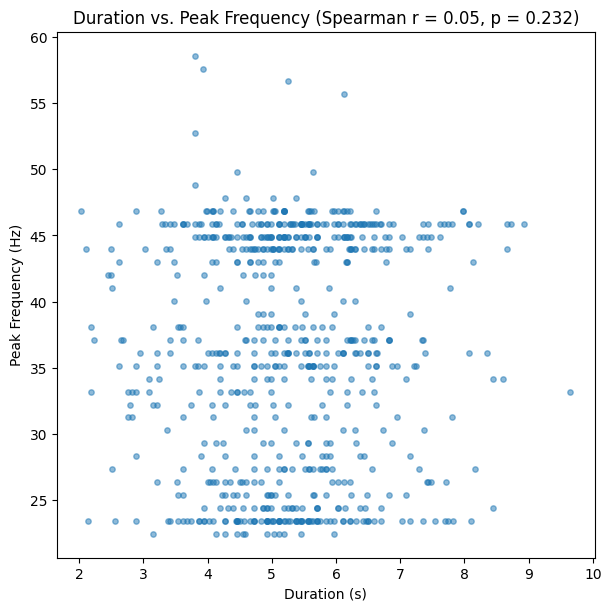

In [10]:
from scipy.stats import spearmanr, pearsonr

spearman_corr, spearman_p = spearmanr(call_df['duration'], call_df['peak_freq'])
pearson_corr, pearson_p = pearsonr(call_df['duration'], call_df['peak_freq'])

print(f"Spearman r = {spearman_corr:.3f}, p = {spearman_p:.3g}")
print(f"Pearson r  = {pearson_corr:.3f}, p = {pearson_p:.3g}")

fig, ax = plt.subplots(figsize=(6, 6), layout='constrained')
ax.scatter(call_df['duration'], call_df['peak_freq'], alpha=0.5, s=15)
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_title(f'Duration vs. Peak Frequency (Spearman r = {spearman_corr:.2f}, p = {spearman_p:.3g})')
plt.show()


### Call-Rate Change-Point Analysis

Jesse suggested aggregating duration and peak frequency over the call-rate time periods identified
by change point analysis, referencing figures 3–4 in Pardo *et al.* 2024 as an example of how to
present this kind of grouped comparison (boxplots of an acoustic feature across identified
groups/periods).

We bin calls into hourly counts (call rate) and run the PELT change-point detection algorithm
(`ruptures`, RBF cost) on that rate series to identify periods of distinct calling activity. We
then compare duration and peak frequency across the detected periods the same way the paper
compares acoustic features across groups.

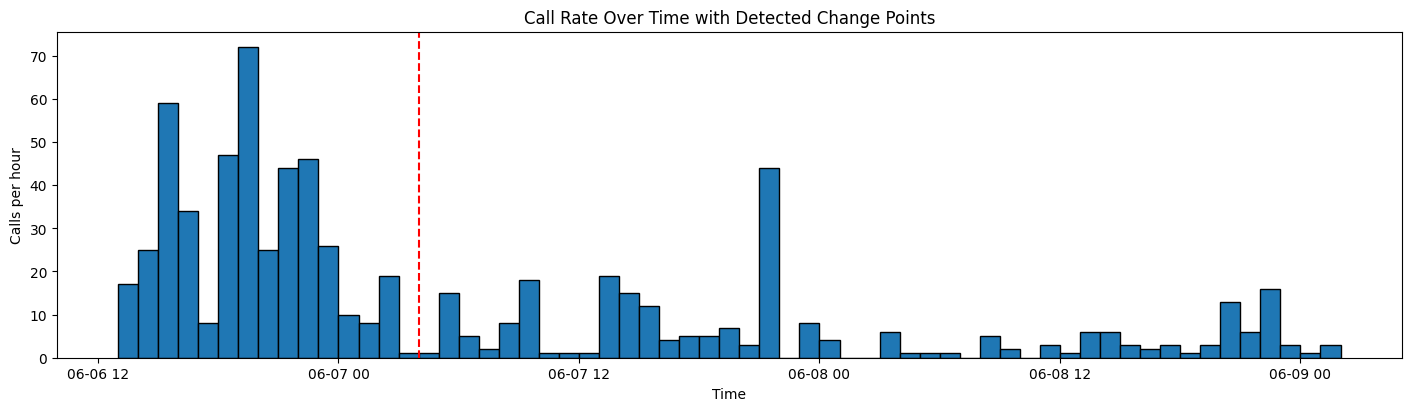

Detected 1 change point(s) at: [Timestamp('2025-06-07 04:00:00')]


In [11]:
import numpy as np
import ruptures as rpt

call_rate = call_df['duration'].resample('1H').count()
signal = call_rate.to_numpy(dtype=float).reshape(-1, 1)

# PELT with RBF cost; pen controls sensitivity (higher = fewer, coarser periods)
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=3)  # last entry is always len(signal)

change_times = [call_rate.index[bp] for bp in breakpoints[:-1]]

fig, ax = plt.subplots(figsize=(14, 4), layout='constrained')
ax.bar(call_rate.index, call_rate.to_numpy(), width=1 / 24, align='edge', edgecolor='black')
for t in change_times:
    ax.axvline(t, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Time')
ax.set_ylabel('Calls per hour')
ax.set_title('Call Rate Over Time with Detected Change Points')
plt.show()

print(f"Detected {len(change_times)} change point(s) at: {change_times}")


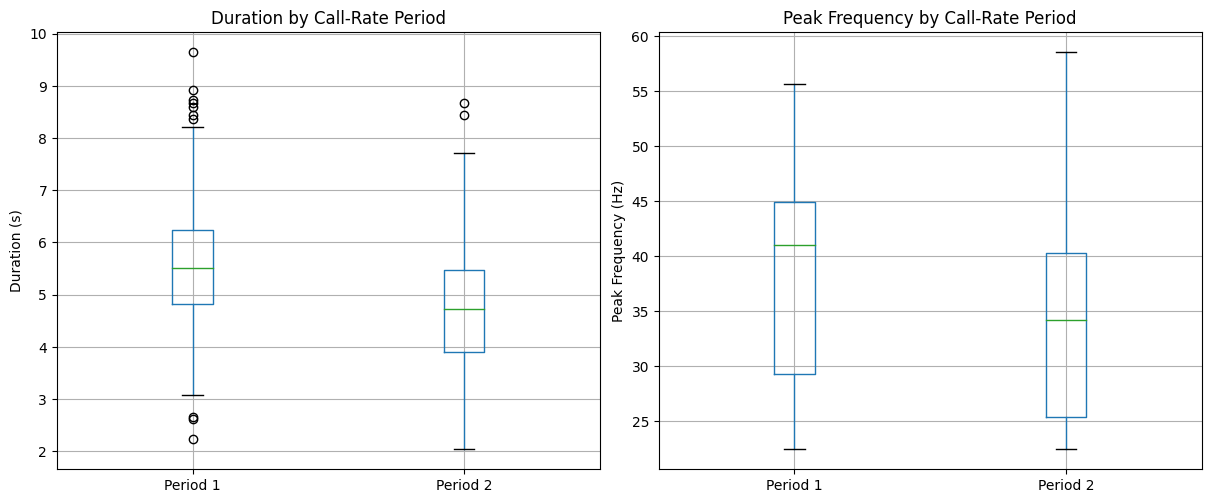

duration                  peak_freq                
              mean       std count       mean       std count
period                                                       
Period 1  5.589176  1.140711   441  37.705056  8.635430   441
Period 2  4.703650  1.203475   264  33.861565  8.356561   264

In [12]:
period_edges = (
    [call_rate.index[0]]
    + change_times
    + [call_rate.index[-1] + pd.Timedelta(hours=1)]
)
period_labels = [f'Period {i + 1}' for i in range(len(period_edges) - 1)]

call_df['period'] = pd.cut(
    call_df.index,
    bins=period_edges,
    labels=period_labels,
    right=False,
    include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
call_df.boxplot(column='duration', by='period', ax=axes[0])
axes[0].set_title('Duration by Call-Rate Period')
axes[0].set_xlabel('')
axes[0].set_ylabel('Duration (s)')

call_df.boxplot(column='peak_freq', by='period', ax=axes[1])
axes[1].set_title('Peak Frequency by Call-Rate Period')
axes[1].set_xlabel('')
axes[1].set_ylabel('Peak Frequency (Hz)')

plt.suptitle('')
plt.show()

period_summary = call_df.groupby('period', observed=True)[['duration', 'peak_freq']].agg(['mean', 'std', 'count'])
period_summary
